In [3]:
#movie realsed per year

import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

movies = pd.read_csv("/Users/meetnakrani/Library/Mobile Documents/com~apple~CloudDocs/recommendation-engine-platform/data/processed/movies_clean.csv")
links = pd.read_csv("/Users/meetnakrani/Library/Mobile Documents/com~apple~CloudDocs/recommendation-engine-platform/data/processed/links_clean.csv")
ratings = pd.read_csv("/Users/meetnakrani/Library/Mobile Documents/com~apple~CloudDocs/recommendation-engine-platform/data/processed/ratingss_clean.csv")
tags = pd.read_csv("/Users/meetnakrani/Library/Mobile Documents/com~apple~CloudDocs/recommendation-engine-platform/data/processed/tags_clean.csv")

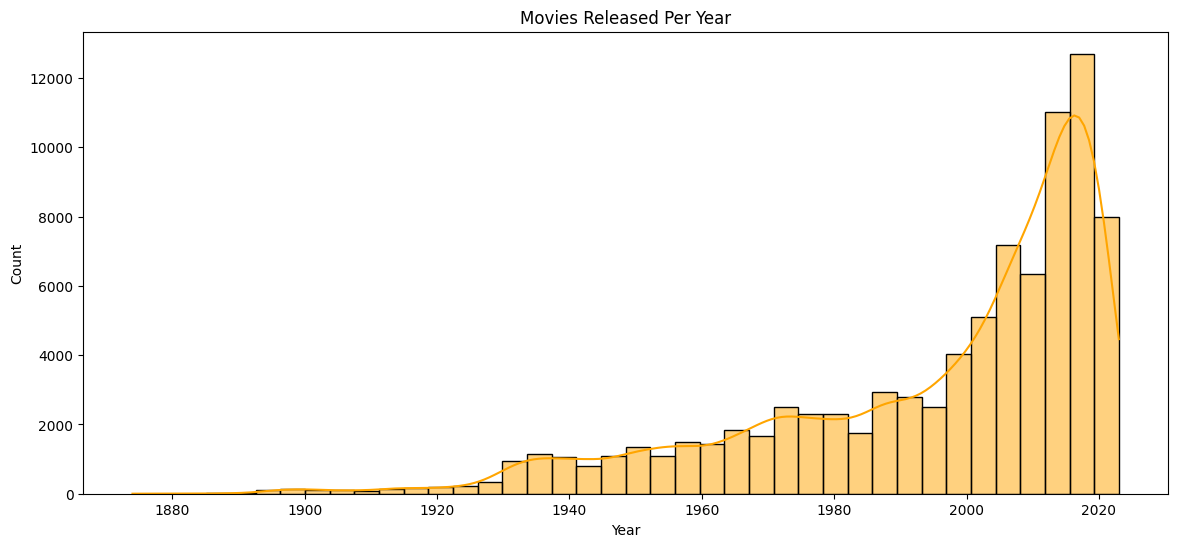

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.histplot(
    movies['year'],
    bins=40,
    kde=True,
    color = "orange"
)

plt.title('Movies Released Per Year')
plt.xlabel('Year')
plt.ylabel('Count')

plt.show()

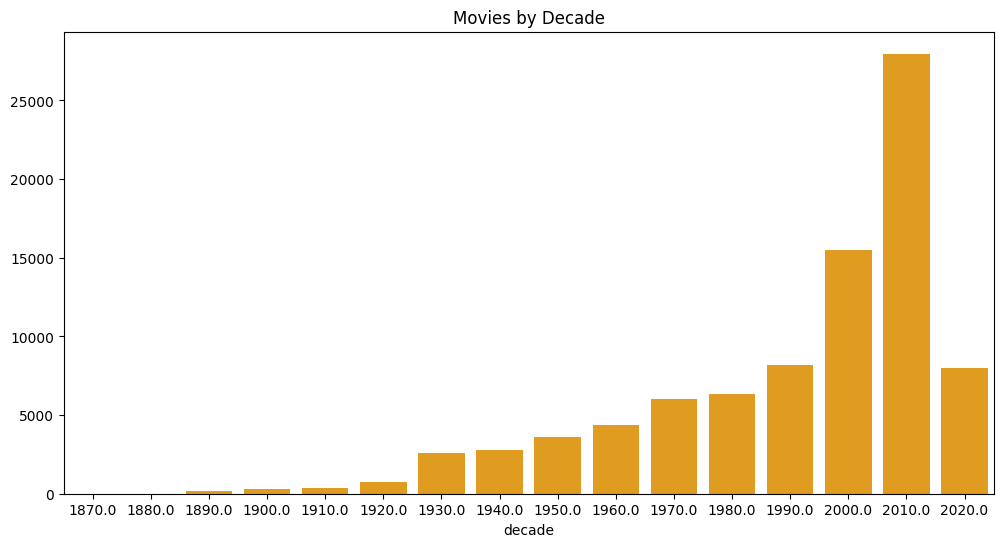

In [4]:

movies['decade'] = (movies["year"]//10)*10

decade_count = movies['decade'].value_counts().sort_index()

plt.figure(figsize=(12,6))

sns.barplot(
    x=decade_count.index,
    y=decade_count.values,
    color="orange"
)

plt.title("Movies by Decade")

plt.show() 

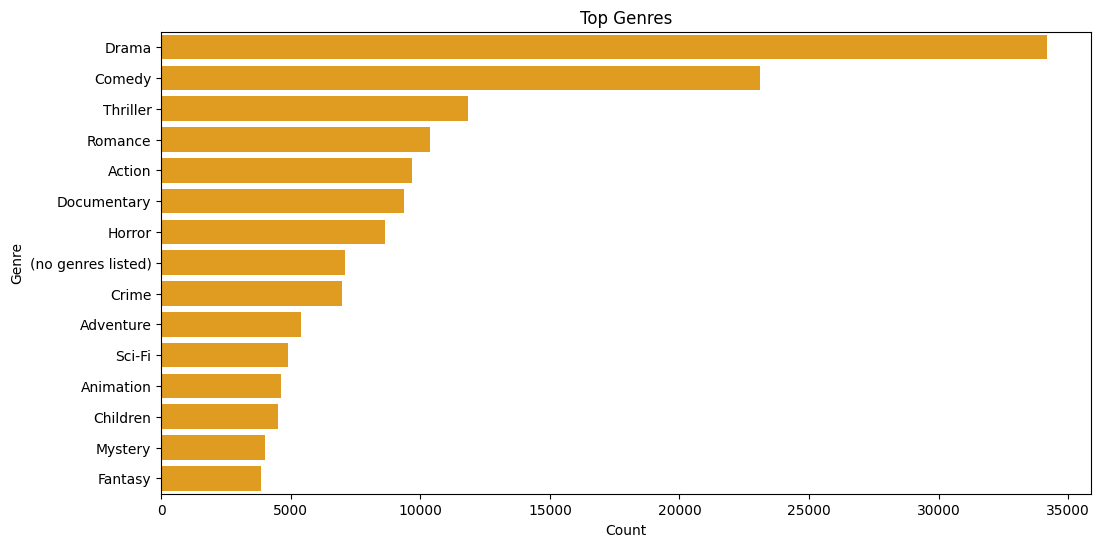

In [5]:
from collections import Counter

genre_counter = Counter()

for genres in movies['genre_list'].dropna():
    genres = str(genres).replace("[","").replace("]","").replace("'","")
    
    for g in genres.split(","):
        genre_counter[g.strip()] += 1

genre_df = pd.DataFrame(
    genre_counter.items(),
    columns=['Genre','Count']
)

genre_df = genre_df.sort_values(
    'Count',
    ascending=False
).head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    data=genre_df,
    color="orange",
    x='Count',
    y='Genre'
)

plt.title('Top Genres')

plt.show()

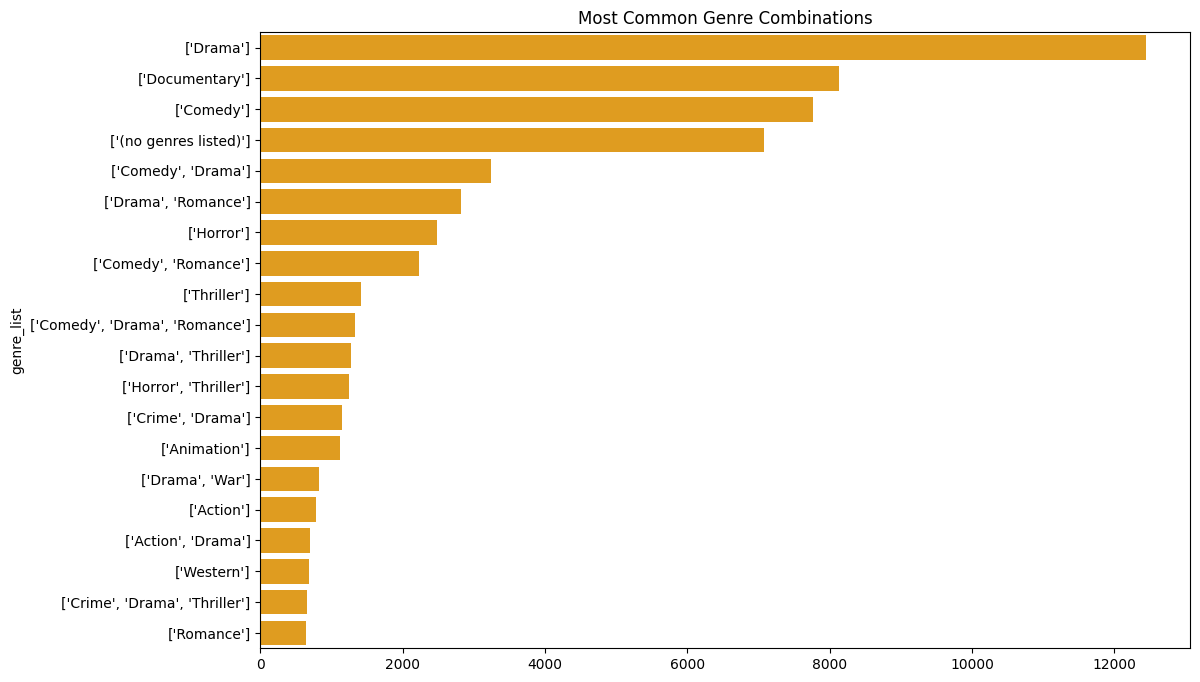

In [6]:
combo = movies['genre_list'].astype(str)

top_combo = combo.value_counts().head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    x=top_combo.values,
    y=top_combo.index,
    color ="orange"
)

plt.title("Most Common Genre Combinations")

plt.show()

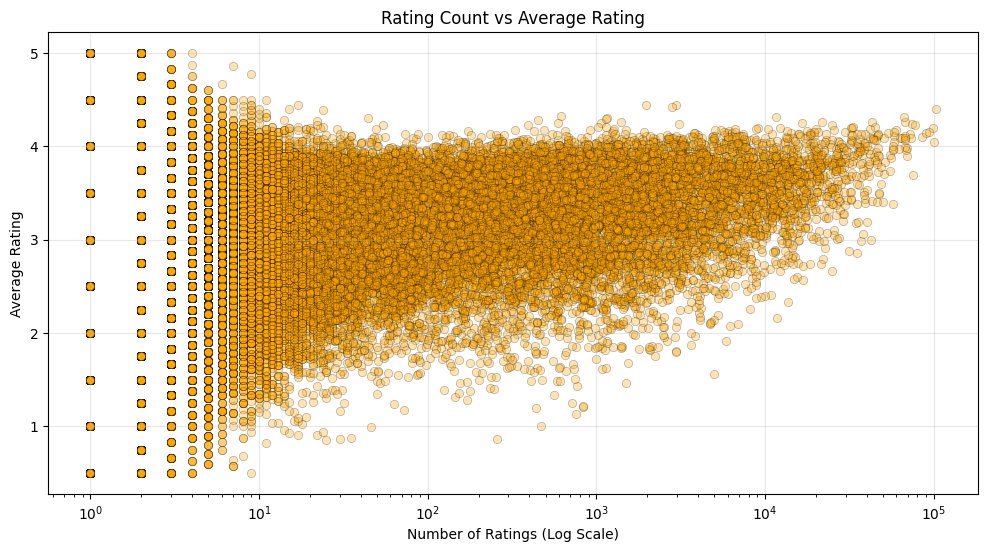

In [17]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=movies,
    x='rating_count_x',
    y='avg_rating_x',
    color = "orange",
    alpha = 0.3,
    edgecolor = "black"
)

plt.xscale('log')

plt.title('Rating Count vs Average Rating')
plt.xlabel('Number of Ratings (Log Scale)')
plt.ylabel('Average Rating')

plt.grid(alpha=0.3)

plt.show()

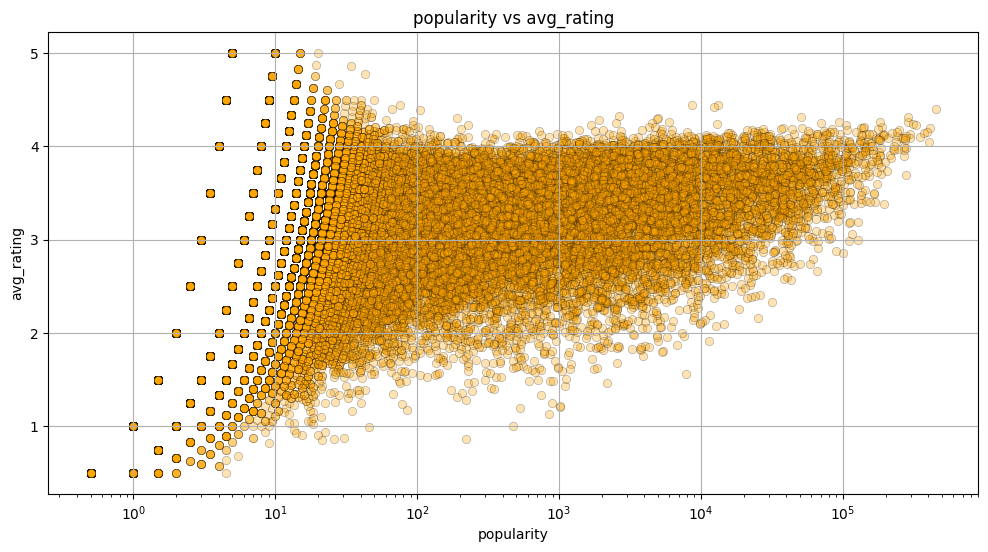

In [42]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data= movies,
    x = "popularity_score_x",
    y = "avg_rating_x",
    color = "orange",
    edgecolor = "black",
    alpha = 0.3
)
plt.xscale("log")
plt.title("popularity vs avg_rating")
plt.xlabel("popularity")
plt.ylabel("avg_rating")
plt.grid()
plt.show()



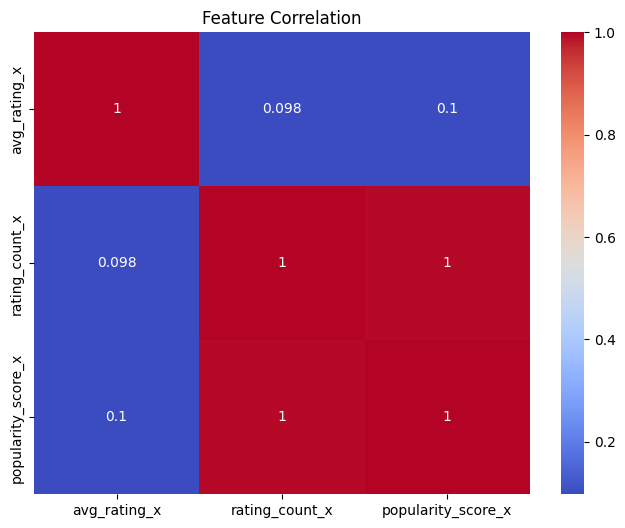

In [31]:
cols = [
    'avg_rating_x',
    'rating_count_x',
    'popularity_score_x'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    movies[cols].corr(),
    annot=True,
    cmap='coolwarm'
   
)

plt.title("Feature Correlation")
plt.show()

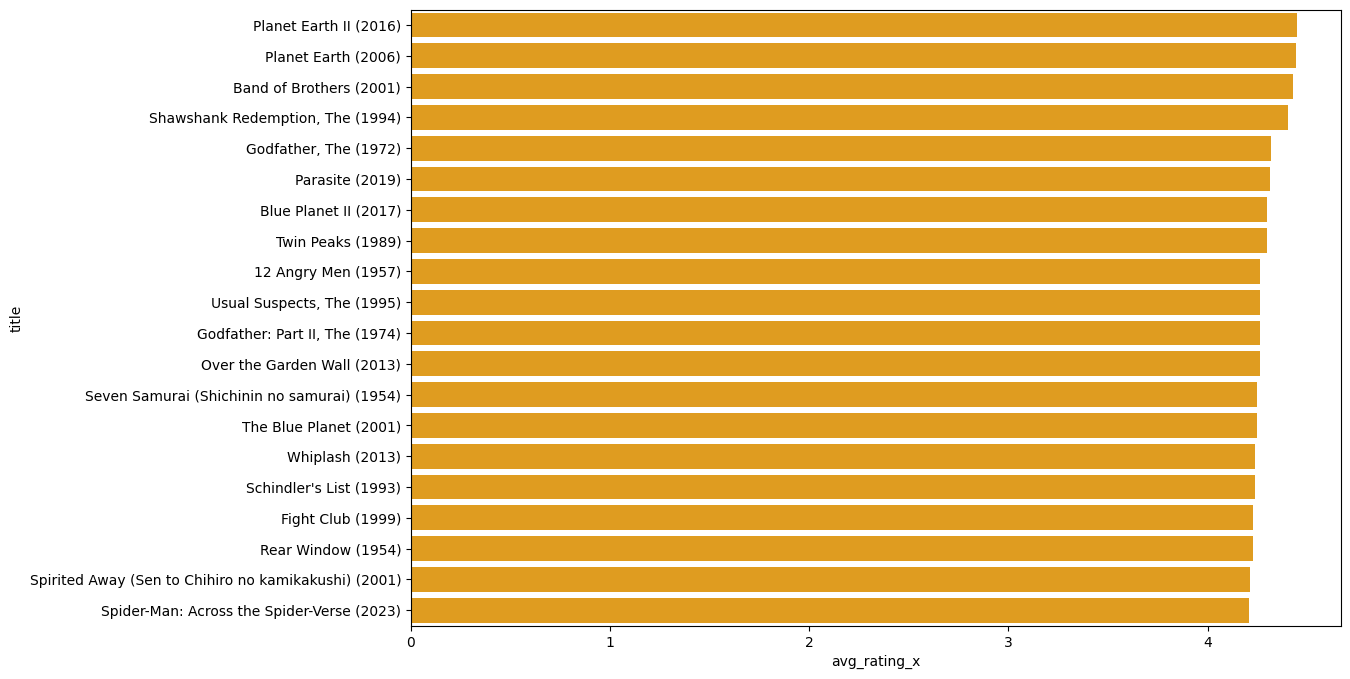

In [40]:
top_movies = (
    movies[
        movies['rating_count_x']>1000
    ]
    .sort_values(
        'avg_rating_x',
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x='avg_rating_x',
    y='title',
    data=top_movies,
    color="orange"
)

plt.show()

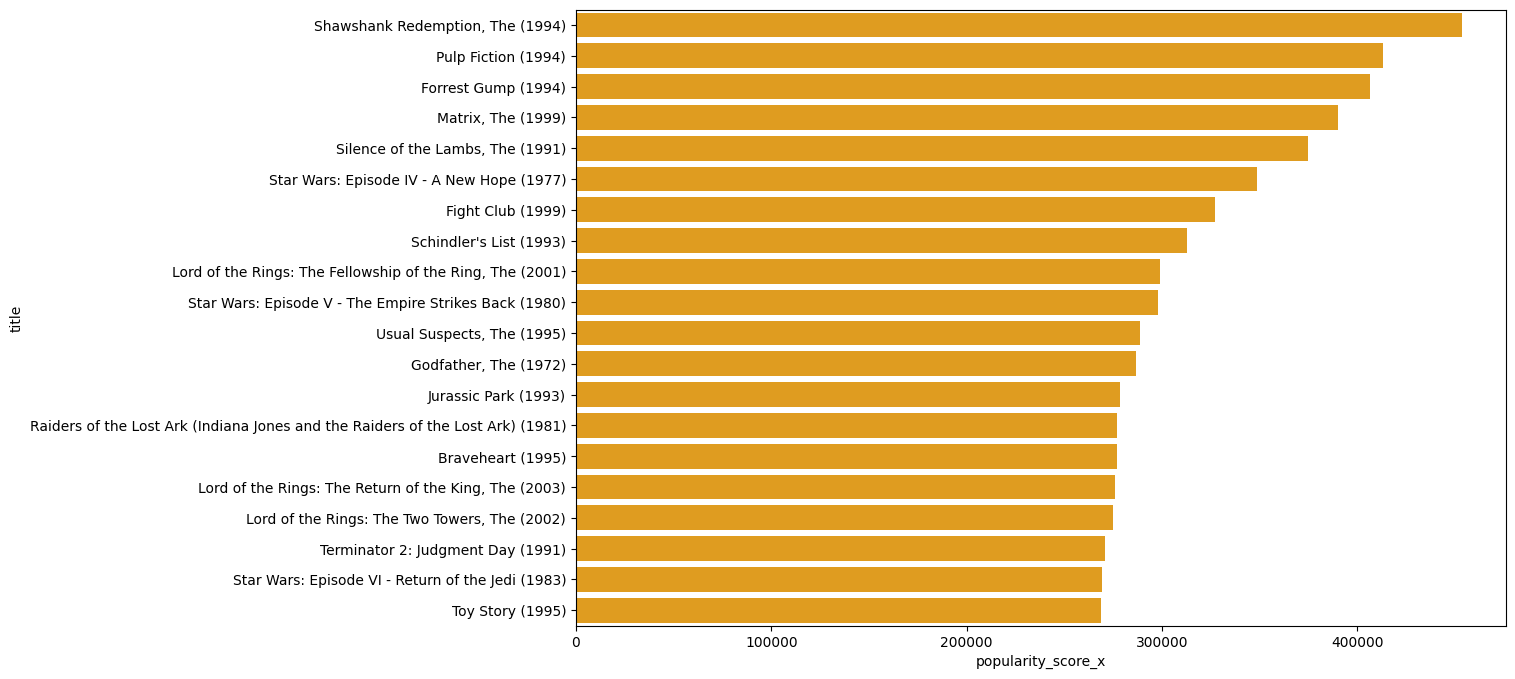

In [43]:
top_pop = movies.sort_values(
    'popularity_score_x',
    ascending=False
).head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    x='popularity_score_x',
    y='title',
    data=top_pop,
    color = "orange"
)

plt.show()

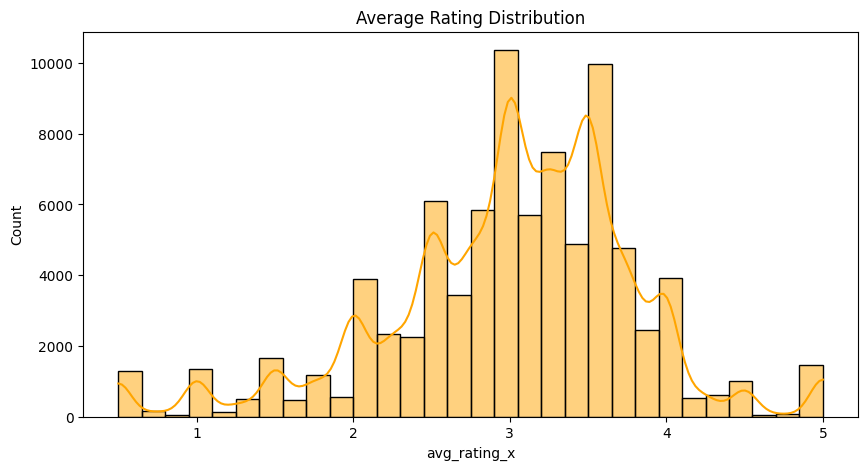

In [47]:
plt.figure(figsize=(10,5))

sns.histplot(
    movies['avg_rating_x'],
    bins=30,
    kde=True,
    color = "orange"
)

plt.title(
    "Average Rating Distribution"
)

plt.show()

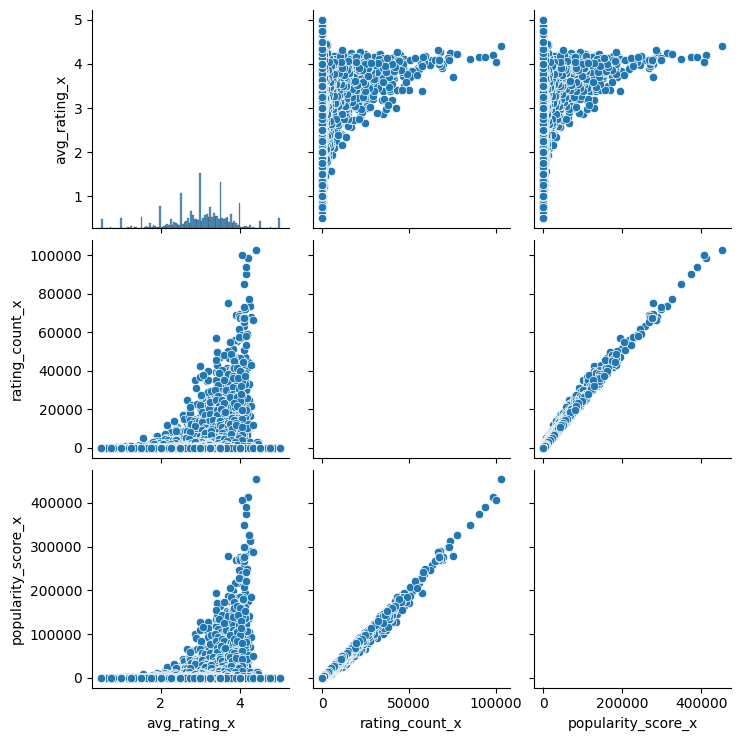

In [49]:
cols = [
    'avg_rating_x',
    'rating_count_x',
    'popularity_score_x'
]

sns.pairplot(
    movies[cols]
)

plt.show()

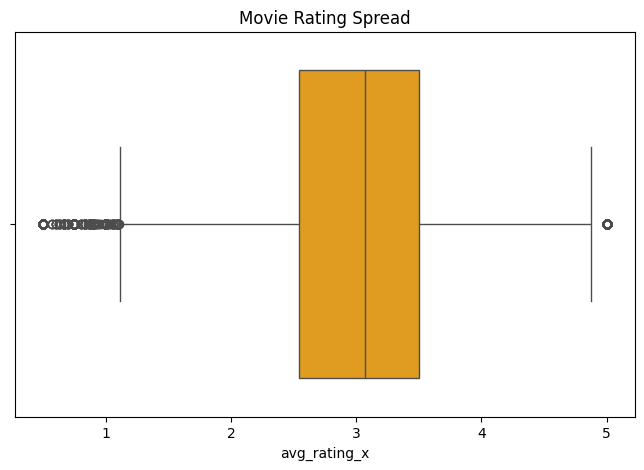

In [51]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=movies['avg_rating_x'],
    color="orange"
)

plt.title(
    "Movie Rating Spread"
)

plt.show()

['movieId', 'imdbId', 'tmdbId']


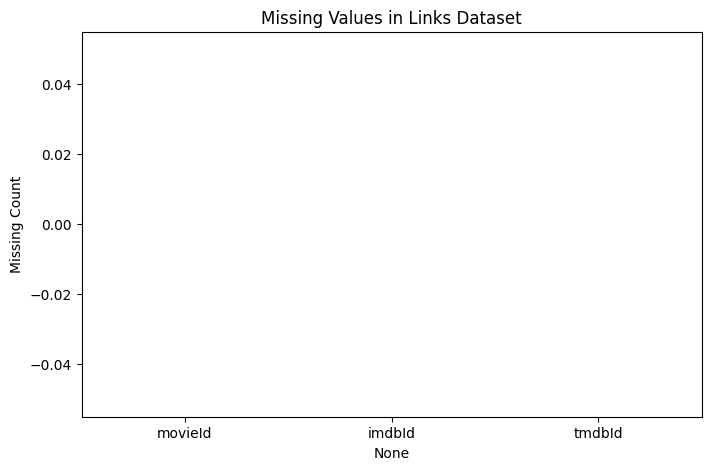

In [54]:
print(links.columns.tolist())
missing = links.isnull().sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=missing.index,
    y=missing.values
)

plt.title("Missing Values in Links Dataset")
plt.ylabel("Missing Count")

plt.show()

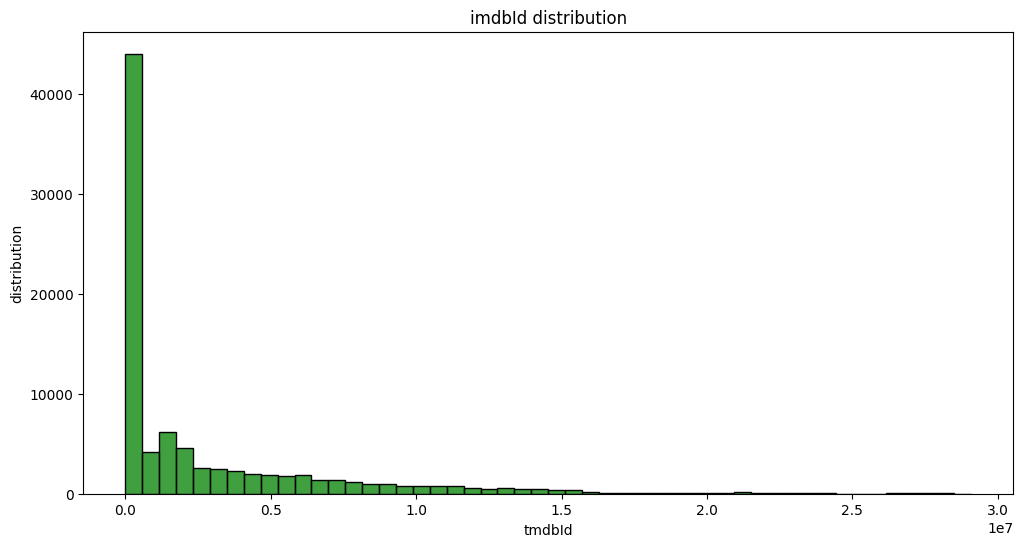

In [62]:
plt.figure(figsize=(12,6))

sns.histplot(
    links["imdbId"],
    bins = 50,
    color = "green"
)
plt.title("imdbId distribution")
plt.xlabel("tmdbId")
plt.ylabel("distribution")
plt.show()

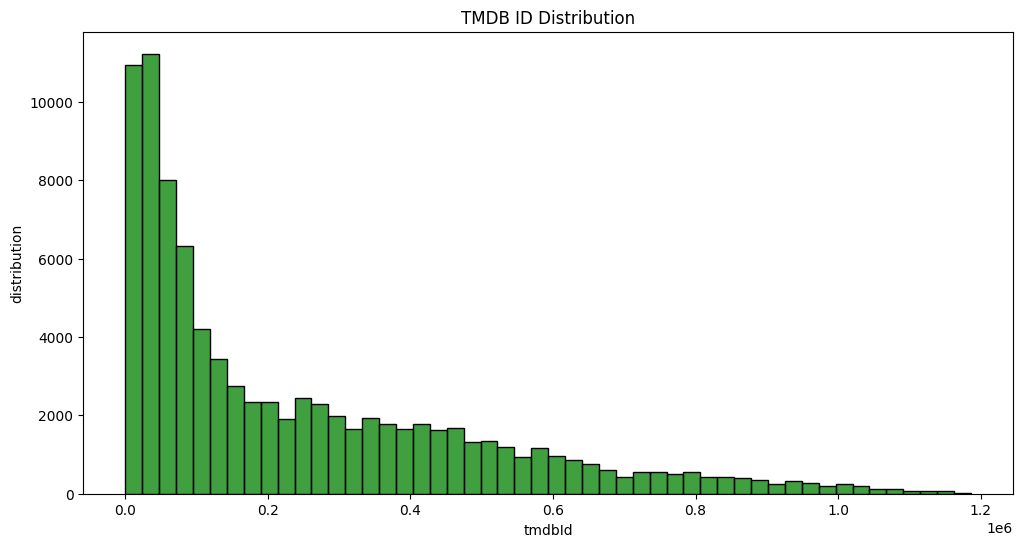

In [63]:
plt.figure(figsize=(12,6))

sns.histplot(
    links['tmdbId'],
    bins=50,
    color = "green"
)

plt.title("TMDB ID Distribution")
plt.xlabel("tmdbId")
plt.ylabel("distribution")

plt.show()

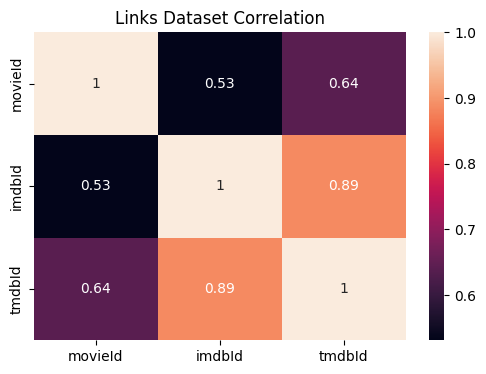

In [64]:
plt.figure(figsize=(6,4))

sns.heatmap(
    links[['movieId','imdbId','tmdbId']].corr(),
    annot=True
)

plt.title("Links Dataset Correlation")

plt.show()

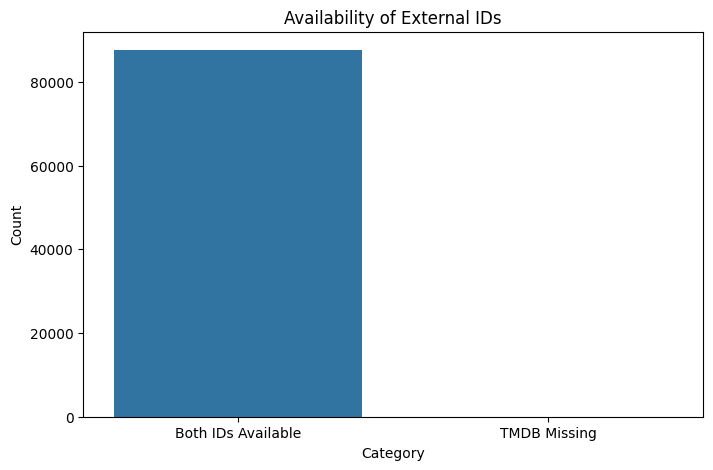

In [65]:
both_ids = (
    links['imdbId'].notna() &
    links['tmdbId'].notna()
).sum()

missing_tmdb = links['tmdbId'].isna().sum()

summary = pd.DataFrame({
    'Category':[
        'Both IDs Available',
        'TMDB Missing'
    ],
    'Count':[
        both_ids,
        missing_tmdb
    ]
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=summary,
    x='Category',
    y='Count'
)

plt.title("Availability of External IDs")

plt.show()

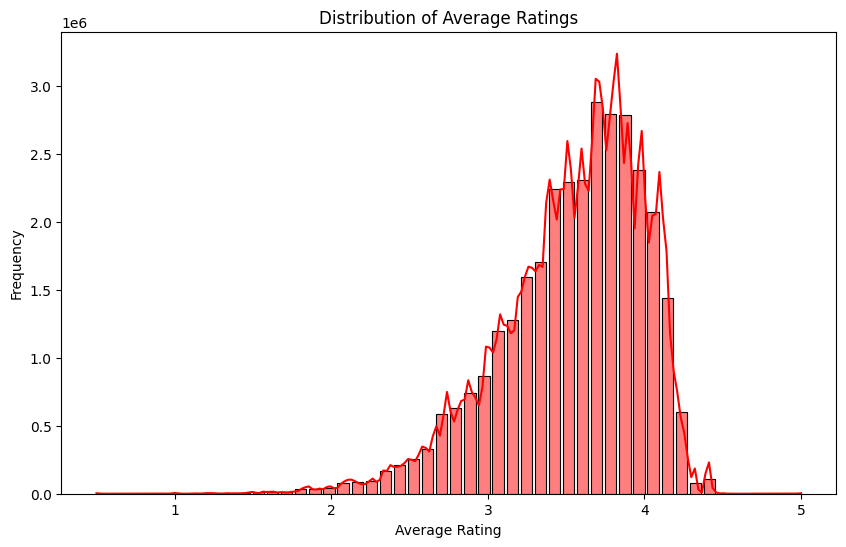

In [72]:
plt.figure(figsize=(10,6))

sns.histplot(
    ratings['avg_rating'],
    bins=50,
    kde=True,
    color = "red",
    edgecolor = "black",
    shrink=0.8
)

plt.title("Distribution of Average Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Frequency")

plt.show()

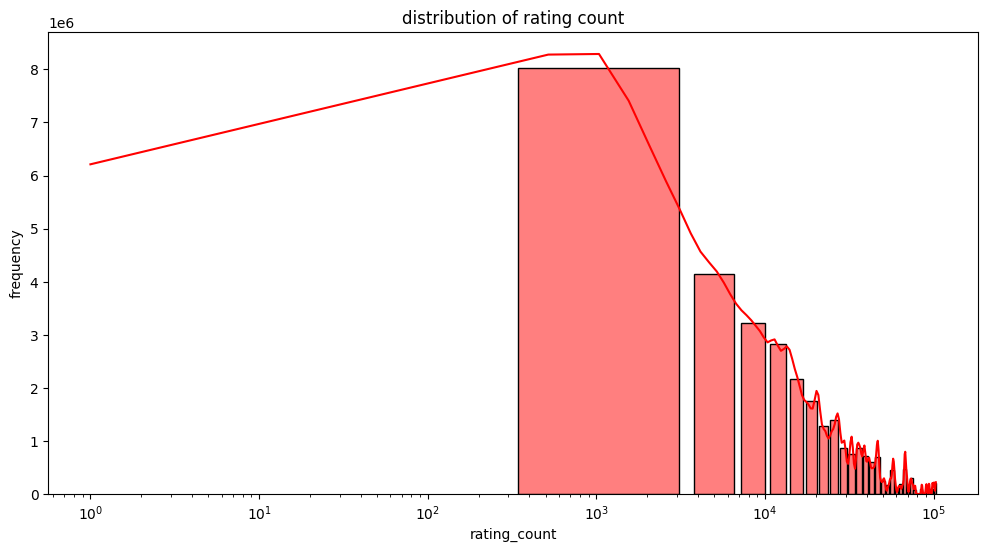

In [80]:
plt.figure(figsize=(12,6))

sns.histplot(
    ratings["rating_count"],
    bins= 60,
    color = "red",
    edgecolor = "black",
    kde = True,
    shrink= 0.8
)
plt.xscale("log")
plt.title("distribution of rating count")
plt.xlabel("rating_count")
plt.ylabel("frequency")
plt.show()

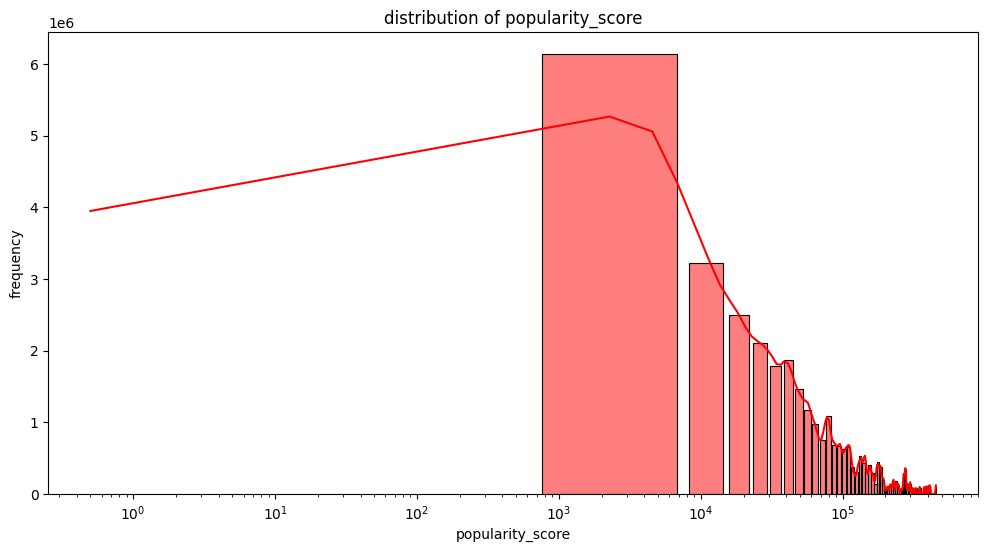

In [81]:
plt.figure(figsize=(12,6))

sns.histplot(
    ratings["popularity_score"],
    bins= 60,
    color = "red",
    edgecolor = "black",
    kde = True,
    shrink= 0.8
)
plt.xscale("log")
plt.title("distribution of popularity_score")
plt.xlabel("popularity_score")
plt.ylabel("frequency")
plt.show()

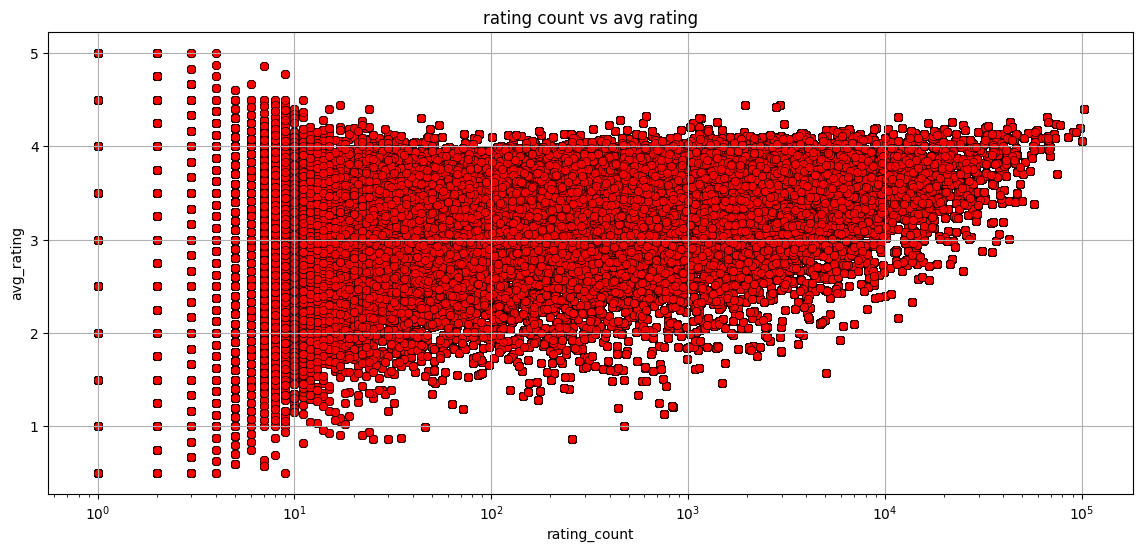

In [8]:
plt.figure(figsize=(14,6))

sns.scatterplot(
    data= ratings,
    x = "rating_count",
    y = "avg_rating",
    color= "red",
    edgecolor = "black",
    alpha = 0.8
)
plt.grid()
plt.xscale("log")
plt.title("rating count vs avg rating")
plt.xlabel("rating_count")
plt.ylabel("avg_rating")
plt.show()

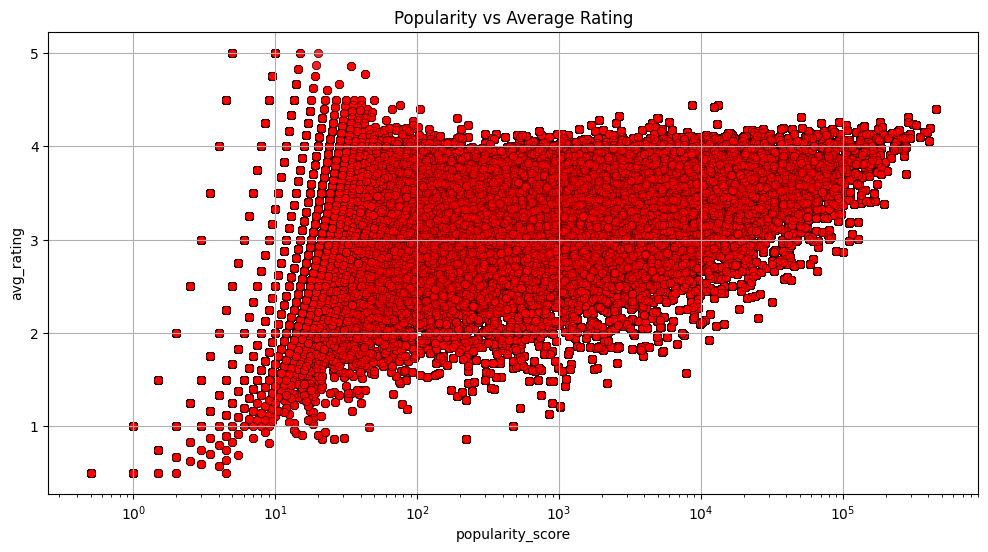

In [9]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=ratings,
    x="popularity_score",
    y="avg_rating",
    alpha=0.4,
    color = "red",
    edgecolor = "black"
)

plt.xscale("log")
plt.grid()

plt.title("Popularity vs Average Rating")

plt.show()

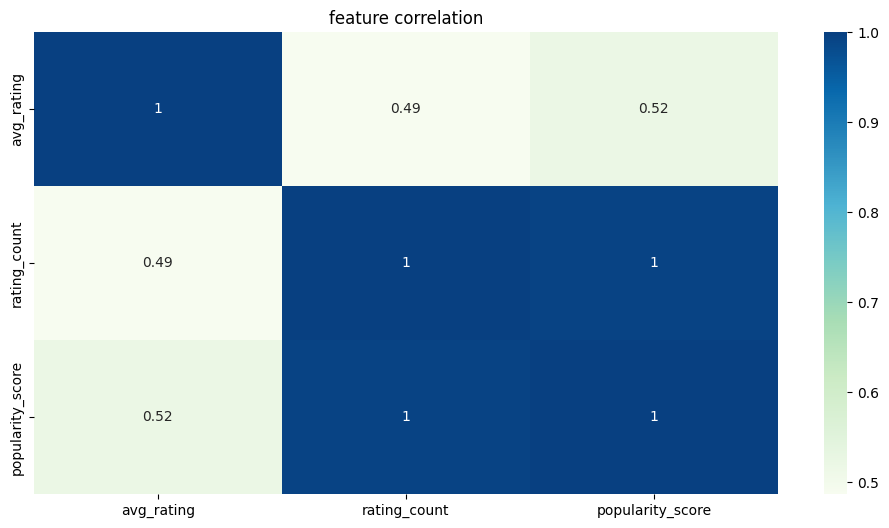

In [10]:
plt.figure(figsize=(12,6))

sns.heatmap(
    ratings[
        [
            "avg_rating",
            "rating_count",
            "popularity_score"
        ]
    ].corr(),
    annot=True,
    cmap="GnBu"
)

plt.title("feature correlation")
plt.show()

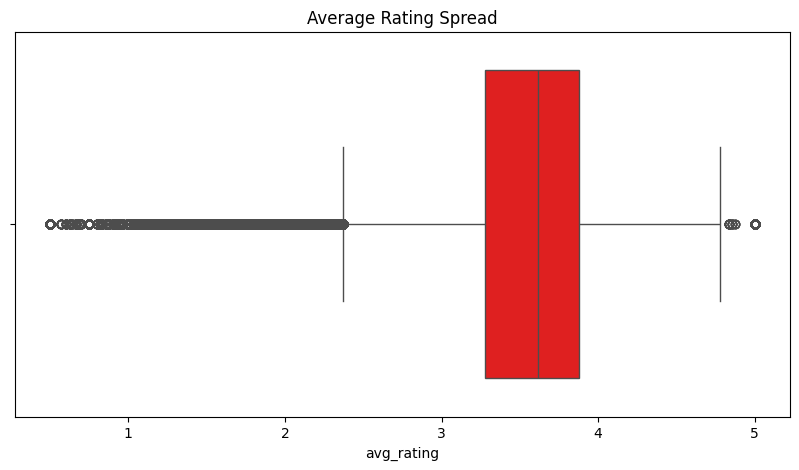

In [12]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=ratings["avg_rating"],
    color="red"
)

plt.title("Average Rating Spread")

plt.show()

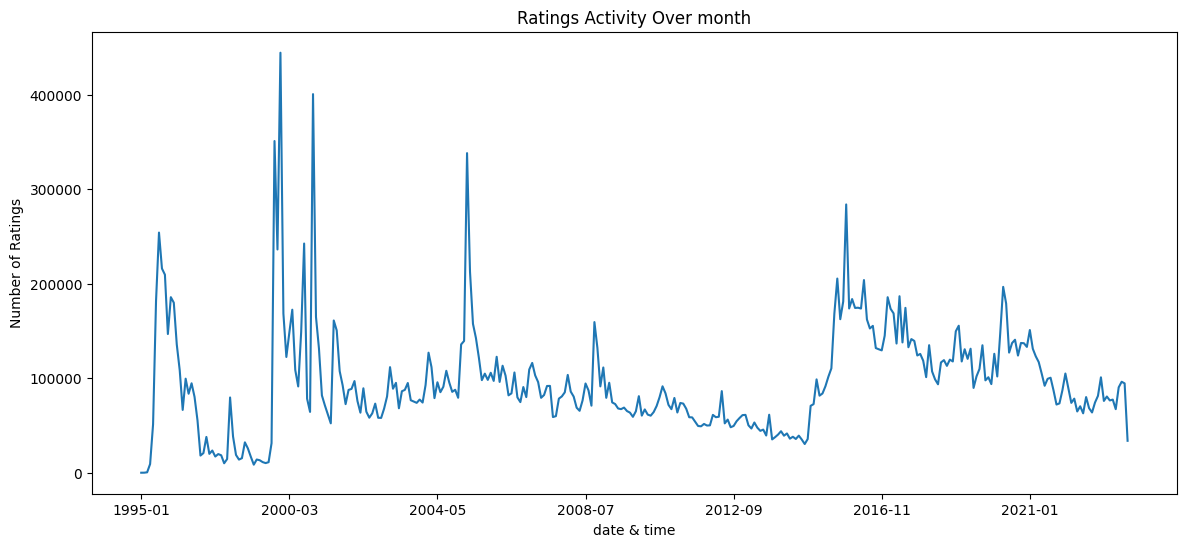

In [20]:
ratings["date & time"] = pd.to_datetime(
    ratings["date & time"]
)

monthly = (
    ratings
    .groupby(
        ratings["date & time"].dt.to_period("M")
    )
    .size()
)

monthly.index = monthly.index.astype(str)

plt.figure(figsize=(14,6))

monthly.plot()

plt.title("Ratings Activity Over month")

plt.ylabel("Number of Ratings")
plt.show()

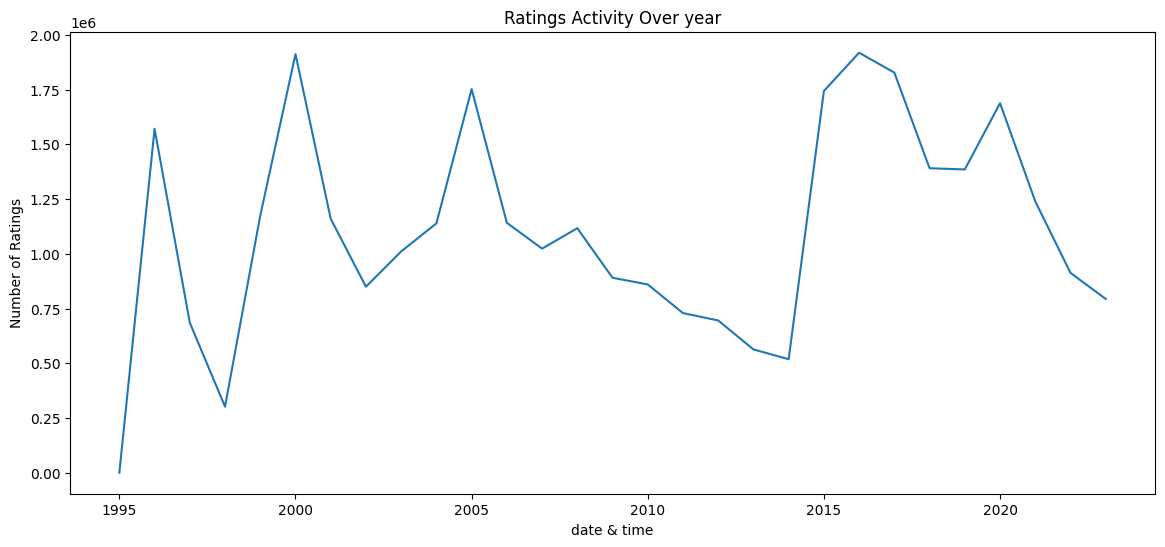

In [21]:
ratings["date & time"] = pd.to_datetime(
    ratings["date & time"]
)

monthly = (
    ratings
    .groupby(
        ratings["date & time"].dt.to_period("Y")
    )
    .size()
)

monthly.index = monthly.index.astype(str)

plt.figure(figsize=(14,6))

monthly.plot()

plt.title("Ratings Activity Over year")

plt.ylabel("Number of Ratings")
plt.show()

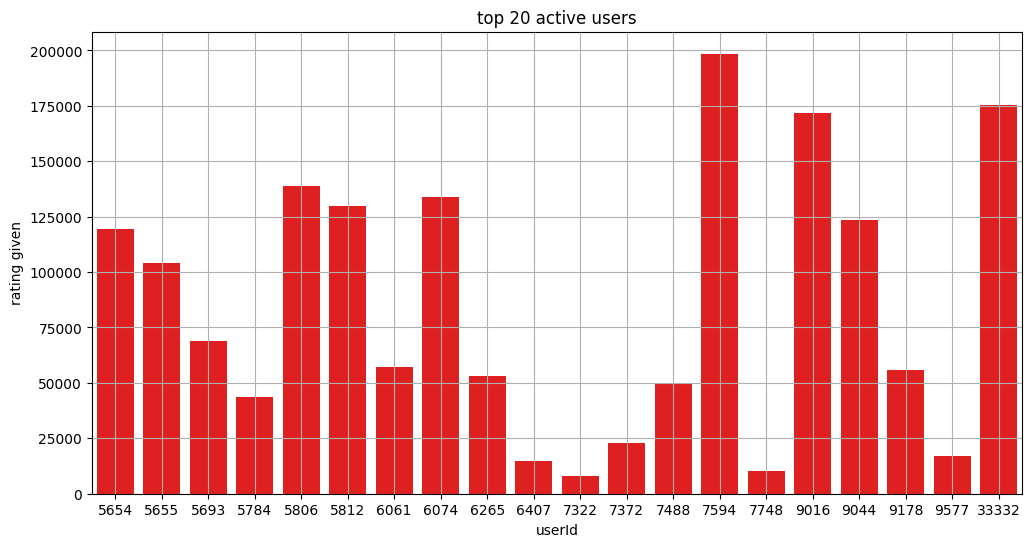

In [23]:
top_users = (
    ratings.groupby("userId")
    .size()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x = top_users.values,
    y = top_users.index,
    color="red"
)

plt.title("top 20 active users")
plt.xlabel("userId")
plt.ylabel("rating given")
plt.grid()
plt.show()

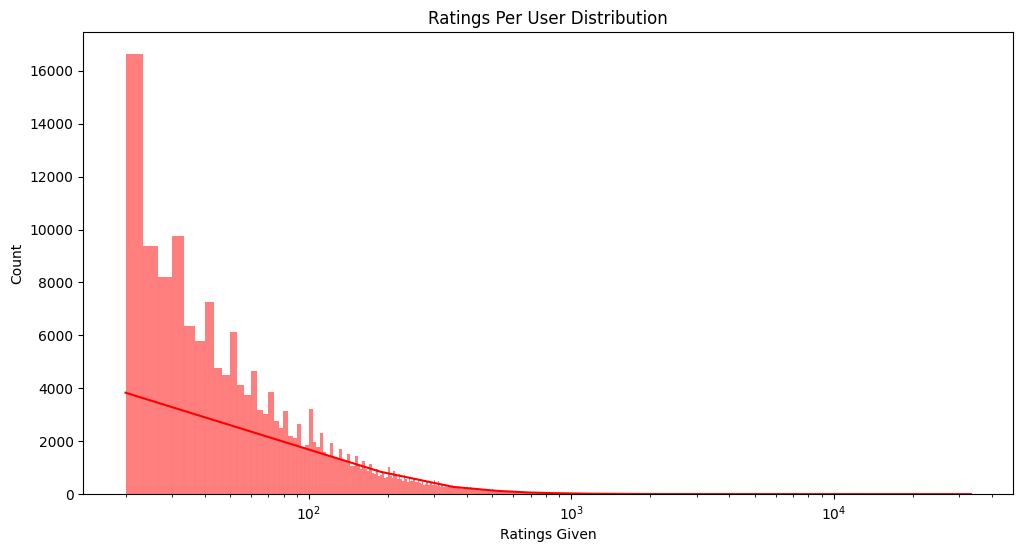

In [28]:
user_activity = (
    ratings
    .groupby("userId")
    .size()
)

plt.figure(figsize=(12,6))

sns.histplot(
    user_activity,
    bins=10000,
    kde=True,
    color= "red",
    edgecolor = "black"
)

plt.xscale("log")

plt.title("Ratings Per User Distribution")

plt.xlabel("Ratings Given")

plt.show()

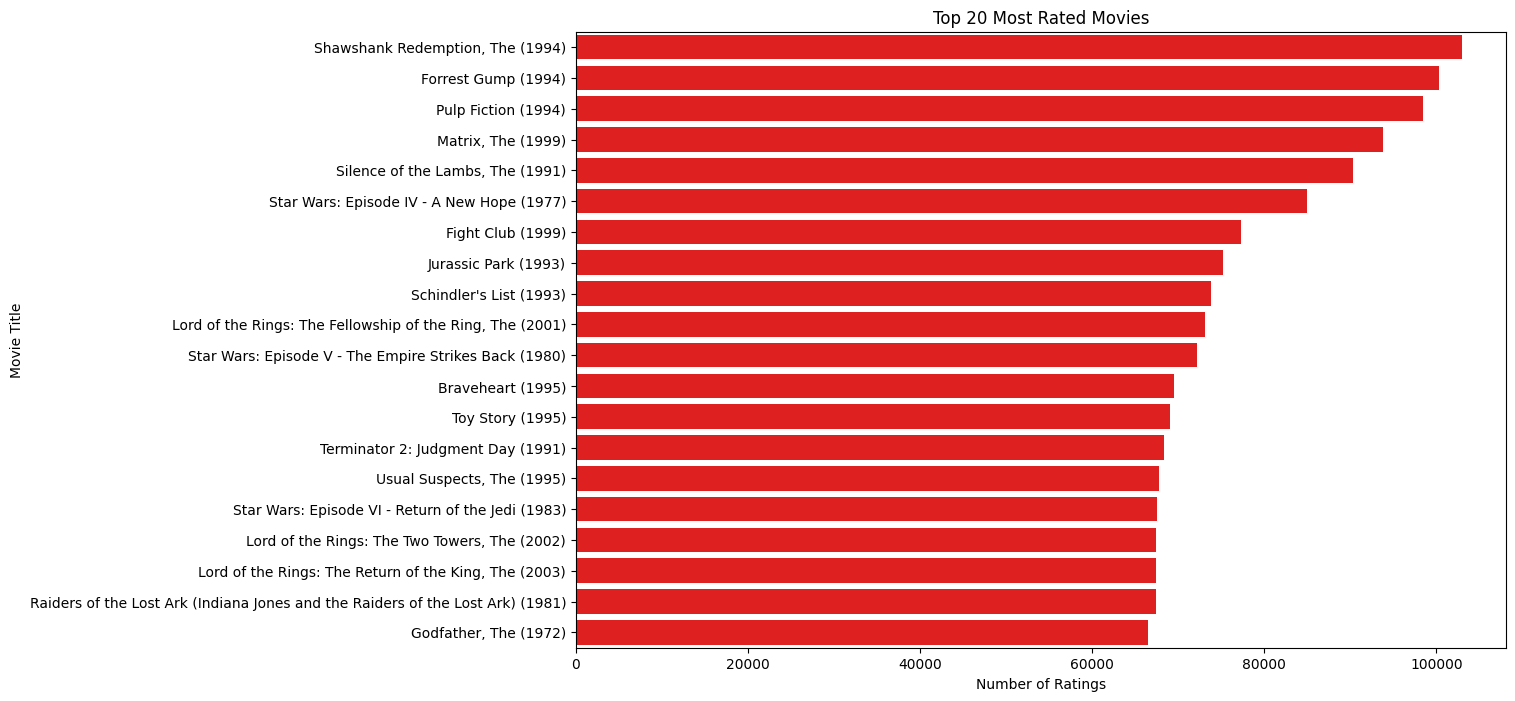

In [34]:
merged_df = pd.merge(
    movies,
    ratings,
    on="movieId",
    how="inner"
)   

top_movie = (
    merged_df.groupby(["movieId", "title"])["rating_count"]
    .max()
    .reset_index()
    .sort_values("rating_count", ascending=False)
    .head(20)
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top_movie,
    x="rating_count",
    y="title",
    color = "red"
)

plt.title("Top 20 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie Title")

plt.show()